<a href="https://colab.research.google.com/github/Sonia1895/PROCESAMIENTO_CLASIFICACION_DATOS/blob/main/Tarea_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea: Redes Neuronales Convolucionales para Segmentación de Caries Dentales

Segmentación semántica de caries en radiografías panorámicas dentales.

**Dataset:** [MLUA (Zzz512/MLUA)](https://github.com/Zzz512/MLUA) — conjunto de imágenes panorámicas dentales con máscaras de segmentación de caries.

**Enfoque:** Se construye una U-Net con un encoder VGG16 preentrenado en ImageNet (transfer learning), siguiendo la misma lógica vista en clase (CNN desde cero → transfer learning → fine-tuning), pero aplicada a una tarea de segmentación en lugar de clasificación.


#Carga de data

In [2]:
import os

# Clonar el repositorio del dataset
if not os.path.isdir("MLUA"):
    !git clone --depth 1 https://github.com/Zzz512/MLUA.git

# Exploramos la estructura de la carpeta de datos para no asumir nombres de subcarpetas
for root, dirs, files in os.walk("MLUA/dataset"):
    nivel = root.replace("MLUA/dataset", "").count(os.sep)
    indent = " " * 2 * nivel
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = " " * 2 * (nivel + 1)
    for f in files[:5]:
        print(f"{sub_indent}{f}")
    if len(files) > 5:
        print(f"{sub_indent}... ({len(files)} archivos en total)")

Cloning into 'MLUA'...
remote: Enumerating objects: 626, done.
remote: Counting objects: 100% (626/626), done.
remote: Compressing objects: 100% (390/390), done.
remote: Total 626 (delta 236), reused 622 (delta 235), pack-reused 0 (from 0)
Receiving objects: 100% (626/626), 243.89 MiB | 46.85 MiB/s, done.
Resolving deltas: 100% (236/236), done.
Updating files: 100% (622/622), done.
dataset/
  test/
    labels/
      1092.png
      810.png
      724.png
      736.png
      1018.png
      ... (100 archivos en total)
    images_cut/
      1092.png
      810.png
      724.png
      736.png
      1018.png
      ... (100 archivos en total)
    colors_cut/
      1092.png
      810.png
      724.png
      736.png
      1018.png
      ... (100 archivos en total)
    labels_cut/
      1092.png
      810.png
      724.png
      736.png
      1018.png
      ... (100 archivos en total)
    colors/
      1092.png
      810.png
      724.png
      736.png
      1018.png
      ... (100 archivos en tot

In [3]:
import glob

# Directorio base del conjunto de prueba
base_dir = "MLUA/dataset/test"

# Nombres reales de las carpetas
IMG_DIRNAME = "images"
MASK_DIRNAME = "labels"

# Construir las rutas
img_dir = os.path.join(base_dir, IMG_DIRNAME)
mask_dir = os.path.join(base_dir, MASK_DIRNAME)

# Verificar que las carpetas existan
if not (os.path.isdir(img_dir) and os.path.isdir(mask_dir)):
    raise FileNotFoundError(
        "No se encontraron las subcarpetas esperadas. "
        "Verifica que existan 'images' y 'labels' dentro de MLUA/dataset/test."
    )

# Obtener las rutas de las imágenes y máscaras
image_paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))
mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))

# Mostrar cantidad de archivos encontrados
print(f"Imágenes encontradas: {len(image_paths)}")
print(f"Máscaras encontradas: {len(mask_paths)}")

# Verificar que coincidan las cantidades
assert len(image_paths) == len(mask_paths), (
    "El número de imágenes y máscaras no coincide"
)

Imágenes encontradas: 100
Máscaras encontradas: 100


#Visualización de ejemplos del dataset

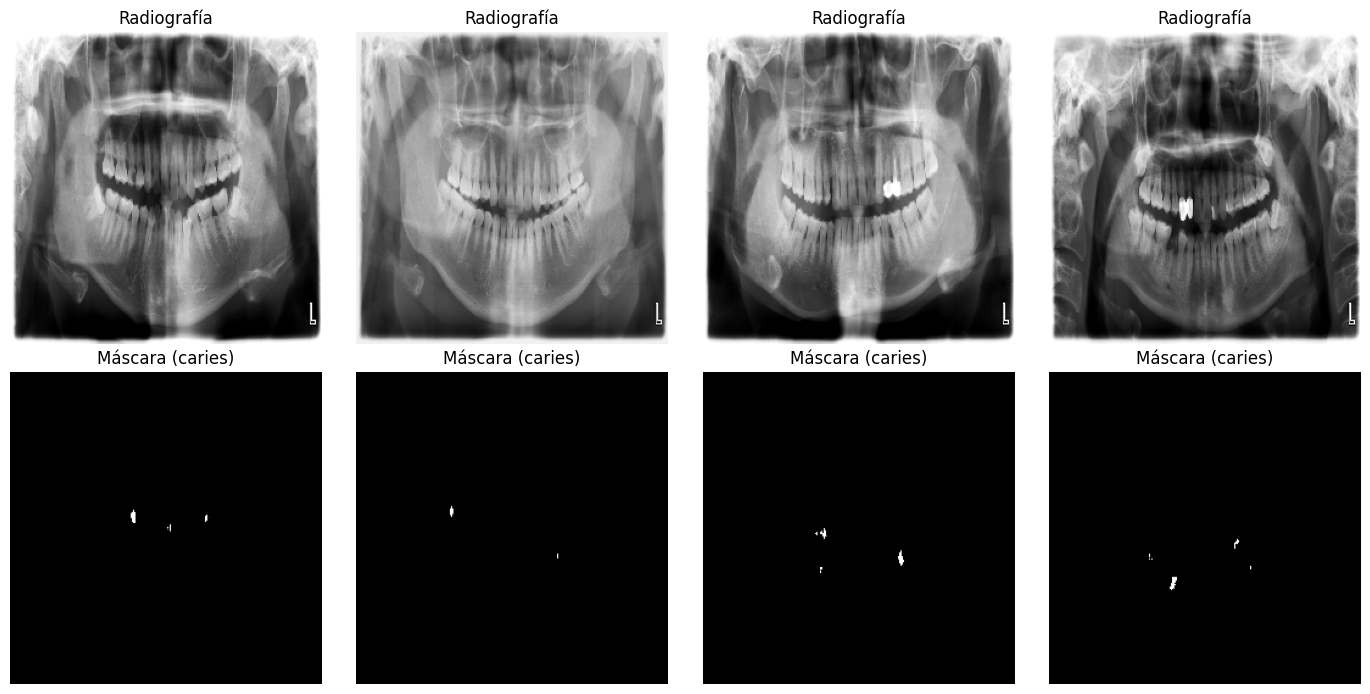

In [14]:
import tensorflow as tf
import matplotlib.pyplot as plt

def cargar_imagen(path, size=(256, 256), mask=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1 if mask else 3, expand_animations=False)
    img = tf.image.resize(img, size)
    return img.numpy().astype("uint8")


# Carpeta donde se guardaran las figuras generadas
os.makedirs('resultados', exist_ok=True)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    im = cargar_imagen(image_paths[i])
    mk = cargar_imagen(mask_paths[i], mask=True)
    axes[0, i].imshow(im)
    axes[0, i].set_title("Radiografía")
    axes[0, i].axis("off")
    axes[1, i].imshow(mk.squeeze(), cmap="gray")
    axes[1, i].set_title("Máscara (caries)")
    axes[1, i].axis("off")
plt.tight_layout()
plt.savefig('resultados/radiografia_mascara.png', dpi=150)
plt.show()

#Preparación del pipeline de datos

Se define una función de preprocesamiento que:
- Redimensiona imágenes y máscaras a un tamaño fijo compatible con VGG16 (224x224).
- Normaliza los valores de la imagen a [0, 1].
- Binariza la máscara (0 = fondo, 1 = caries).
- Divide el conjunto en entrenamiento y validación.

In [8]:
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 8

def preprocess(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, IMG_SIZE, method="nearest")
    mask = tf.cast(mask > 127, tf.float32)  # binarización: caries = 1, fondo = 0

    img.set_shape((*IMG_SIZE, 3))
    mask.set_shape((*IMG_SIZE, 1))
    return img, mask

# División entrenamiento / validación (80% / 20%)
n = len(image_paths)
idx = np.arange(n)
rng = np.random.default_rng(42)
rng.shuffle(idx)
split = int(0.8 * n)
train_idx, val_idx = idx[:split], idx[split:]

def make_dataset(indices, shuffle=False):
    imgs = [image_paths[i] for i in indices]
    masks = [mask_paths[i] for i in indices]
    ds = tf.data.Dataset.from_tensor_slices((imgs, masks))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(imgs), seed=42)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = make_dataset(train_idx, shuffle=True)
val_dataset = make_dataset(val_idx, shuffle=False)

print(f"Ejemplos de entrenamiento: {len(train_idx)}")
print(f"Ejemplos de validación: {len(val_idx)}")

Ejemplos de entrenamiento: 80
Ejemplos de validación: 20


#Construcción del modelo: U-Net con encoder VGG16 (Transfer Learning)

Siguiendo la misma idea de *transfer learning* vista en clase, se reutiliza VGG16 preentrenado en ImageNet como **encoder** (extractor de características), y se construye un **decoder** entrenado desde cero que reconstruye progresivamente la resolución espacial para producir un mapa de segmentación del mismo tamaño que la imagen de entrada. Las conexiones tipo *skip connection* (como en U-Net) combinan características de bajo y alto nivel para mejorar la precisión de los bordes de la lesión.


In [10]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

def bloque_decoder(x, skip, filtros):
    x = layers.Conv2DTranspose(filtros, (2, 2), strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = layers.Conv2D(filtros, (3, 3), activation="relu", padding="same")(x)
    x = layers.Conv2D(filtros, (3, 3), activation="relu", padding="same")(x)
    return x

def construir_unet_vgg16(input_shape=(224, 224, 3)):
    # Encoder preentrenado (transfer learning)
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # se congela el encoder, igual que en la sección de transfer learning vista en clase

    # Capas del encoder usadas como skip connections
    nombres_skip = ["block1_conv2", "block2_conv2", "block3_conv3", "block4_conv3"]
    skips = [base_model.get_layer(n).output for n in nombres_skip]
    cuello = base_model.get_layer("block5_conv3").output  # cuello de botella

    x = cuello
    for skip, filtros in zip(reversed(skips), [512, 256, 128, 64]):
        x = bloque_decoder(x, skip, filtros)

    salida = layers.Conv2D(1, (1, 1), activation="sigmoid")(x)  # mapa de segmentación binario

    return models.Model(inputs=base_model.input, outputs=salida, name="unet_vgg16")

model = construir_unet_vgg16()
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "unet_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 25,854,657 (98.63 MB)

 Trainable params: 11,139,969 (42.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

#Métricas de segmentación

Para segmentación, la exactitud (*accuracy*) por pixel no es suficiente, porque la clase "fondo" domina la imagen. Se agrega el **coeficiente de Dice** y el **Intersection over Union (IoU)**, ambas métricas estándar para evaluar qué tan bien coincide la máscara predicha con la máscara real.


In [11]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    interseccion = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * interseccion + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    interseccion = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - interseccion
    return (interseccion + smooth) / (union + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def loss_combinada(y_true, y_pred):
    # Combina entropía cruzada binaria (estabilidad en el entrenamiento) con Dice loss
    # (mejor manejo del desbalance de clases entre caries y fondo)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_combinada,
    metrics=[dice_coef, iou_coef, "accuracy"]
)

#Entrenamiento del modelo

In [12]:
EPOCHS = 30

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_dice_coef", mode="max", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 233s 23s/step - accuracy: 0.9703 - dice_coef: 0.0014 - iou_coef: 6.9174e-04 - loss: 1.0854 - val_accuracy: 0.9988 - val_dice_coef: 1.5417e-04 - val_iou_coef: 7.7093e-05 - val_loss: 1.0123 - learning_rate: 1.0000e-04
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 246s 22s/step - accuracy: 0.9988 - dice_coef: 5.3988e-05 - iou_coef: 2.6996e-05 - loss: 1.0141 - val_accuracy: 0.9988 - val_dice_coef: 2.6327e-05 - val_iou_coef: 1.3165e-05 - val_loss: 1.0147 - learning_rate: 1.0000e-04
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 271s 23s/step - accuracy: 0.9988 - dice_coef: 3.3991e-05 - iou_coef: 1.6997e-05 - loss: 1.0144 - val_accuracy: 0.9988 - val_dice_coef: 5.4687e-05 - val_iou_coef: 2.7345e-05 - val_loss: 1.0136 - learning_rate: 1.0000e-04
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 215s 22s/step - accuracy: 0.9988 - dice_coef: 1.0194e-04 - iou_coef: 5.0972e-05 - loss: 1.0129 - val_accuracy: 0.9988 - val_dice_coef: 1.8491e-04 - val_iou_coef: 9.2465e-05 - val_loss: 1.0118 

#Resultados: Curvas de entrenamiento

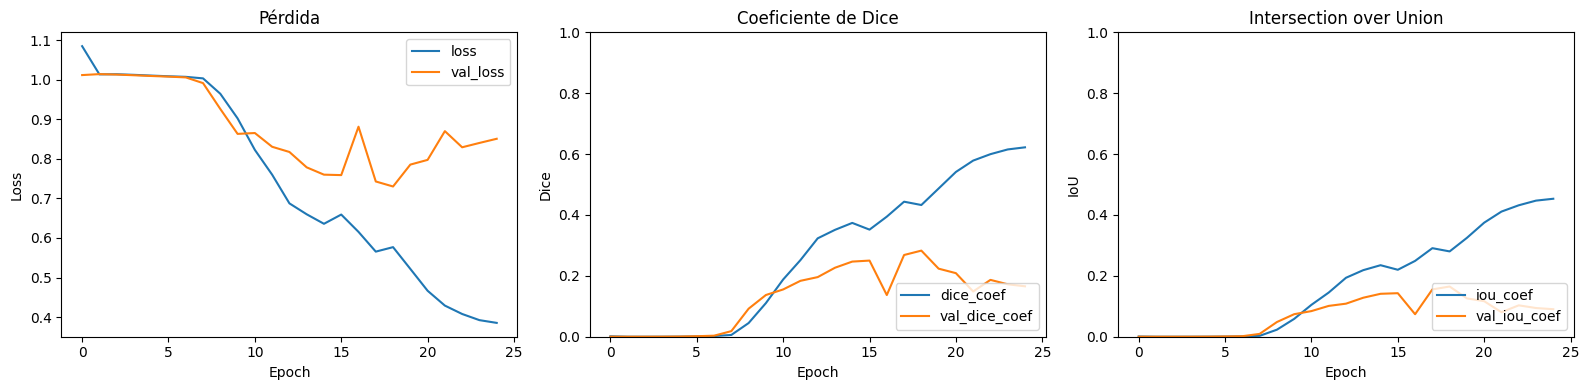

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history["loss"], label="loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Pérdida")

axes[1].plot(history.history["dice_coef"], label="dice_coef")
axes[1].plot(history.history["val_dice_coef"], label="val_dice_coef")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_ylim([0, 1])
axes[1].legend(loc="lower right")
axes[1].set_title("Coeficiente de Dice")

axes[2].plot(history.history["iou_coef"], label="iou_coef")
axes[2].plot(history.history["val_iou_coef"], label="val_iou_coef")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("IoU")
axes[2].set_ylim([0, 1])
axes[2].legend(loc="lower right")
axes[2].set_title("Intersection over Union")

plt.tight_layout()
plt.savefig('resultados/modelos.png', dpi=150)
plt.show()

#Evaluación cuantitativa en el conjunto de validación

In [16]:
resultados = model.evaluate(val_dataset, return_dict=True)
for metrica, valor in resultados.items():
    print(f"{metrica}: {valor:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.9979 - dice_coef: 0.2829 - iou_coef: 0.1650 - loss: 0.7303
accuracy: 0.9979
dice_coef: 0.2829
iou_coef: 0.1650
loss: 0.7303


#Visualización cualitativa de predicciones

Se comparan, para varios ejemplos del conjunto de validación: la radiografía original, la máscara real (*ground truth*) y la máscara predicha por el modelo.

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


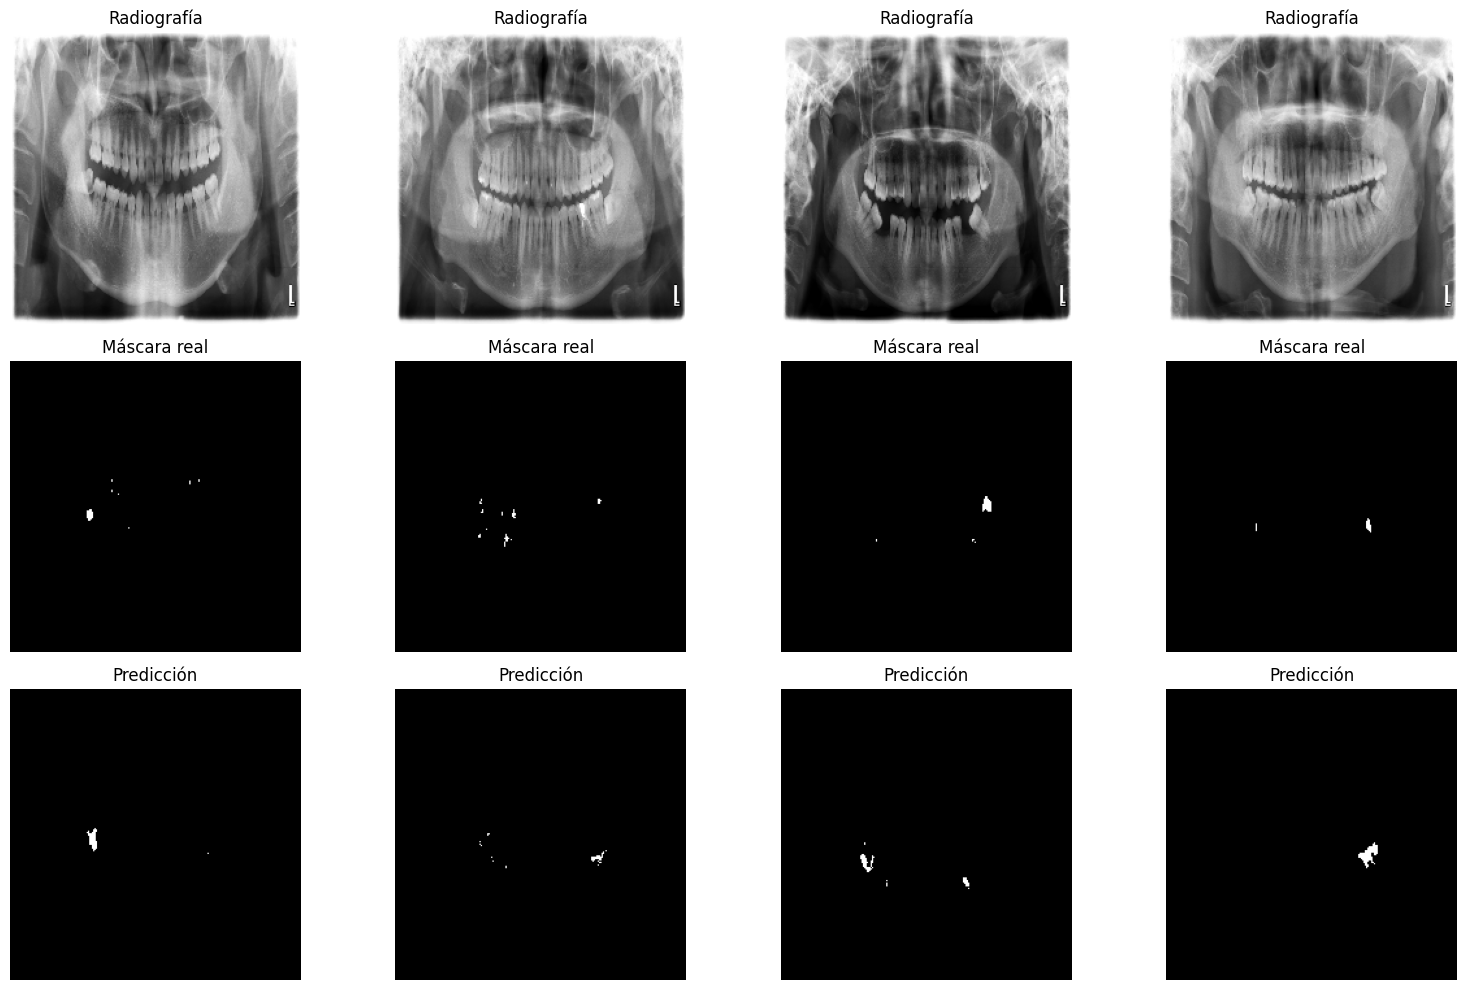

In [18]:
def mostrar_predicciones(dataset, n=4):
    imgs, masks = next(iter(dataset))
    preds = model.predict(imgs)
    preds_bin = (preds > 0.5).astype("float32")

    fig, axes = plt.subplots(3, n, figsize=(4 * n, 10))
    for i in range(n):
        axes[0, i].imshow(imgs[i])
        axes[0, i].set_title("Radiografía")
        axes[0, i].axis("off")

        axes[1, i].imshow(masks[i].numpy().squeeze(), cmap="gray")
        axes[1, i].set_title("Máscara real")
        axes[1, i].axis("off")

        axes[2, i].imshow(preds_bin[i].squeeze(), cmap="gray")
        axes[2, i].set_title("Predicción")
        axes[2, i].axis("off")
    plt.tight_layout()
    plt.savefig('resultados/prediccines.png', dpi=150)
    plt.show()

mostrar_predicciones(val_dataset, n=min(4, BATCH_SIZE))

#Fine-tuning: descongelar las últimas capas del encoder

Siguiendo la misma lógica de *fine-tuning* vista en clase con ResNet50, se puede descongelar la parte final del encoder VGG16 y continuar el entrenamiento con una tasa de aprendizaje baja, para permitir que el extractor de características se ajuste ligeramente al dominio de radiografías dentales.

In [19]:
# Descongelar las últimas capas convolucionales del bloque 5 de VGG16
for layer in model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # tasa de aprendizaje baja para fine-tuning
    loss=loss_combinada,
    metrics=[dice_coef, iou_coef, "accuracy"]
)

history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 226s 22s/step - accuracy: 0.9989 - dice_coef: 0.4890 - iou_coef: 0.3275 - loss: 0.5197 - val_accuracy: 0.9988 - val_dice_coef: 0.1623 - val_iou_coef: 0.0885 - val_loss: 0.8458 - learning_rate: 1.0000e-05
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 263s 22s/step - accuracy: 0.9990 - dice_coef: 0.5221 - iou_coef: 0.3566 - loss: 0.4862 - val_accuracy: 0.9986 - val_dice_coef: 0.2366 - val_iou_coef: 0.1344 - val_loss: 0.7677 - learning_rate: 1.0000e-05
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 223s 22s/step - accuracy: 0.9991 - dice_coef: 0.5397 - iou_coef: 0.3722 - loss: 0.4685 - val_accuracy: 0.9988 - val_dice_coef: 0.1656 - val_iou_coef: 0.0904 - val_loss: 0.8454 - learning_rate: 1.0000e-05
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 222s 22s/step - accuracy: 0.9991 - dice_coef: 0.5426 - iou_coef: 0.3748 - loss: 0.4655 - val_accuracy: 0.9987 - val_dice_coef: 0.1973 - val_iou_coef: 0.1095 - val_loss: 0.8126 - learning_rate: 5.0000e-06
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.9988 - dice_coef: 0.1623 - iou_coef: 0.0885 - loss: 0.8458
accuracy: 0.9988
dice_coef: 0.1623
iou_coef: 0.0885
loss: 0.8458
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


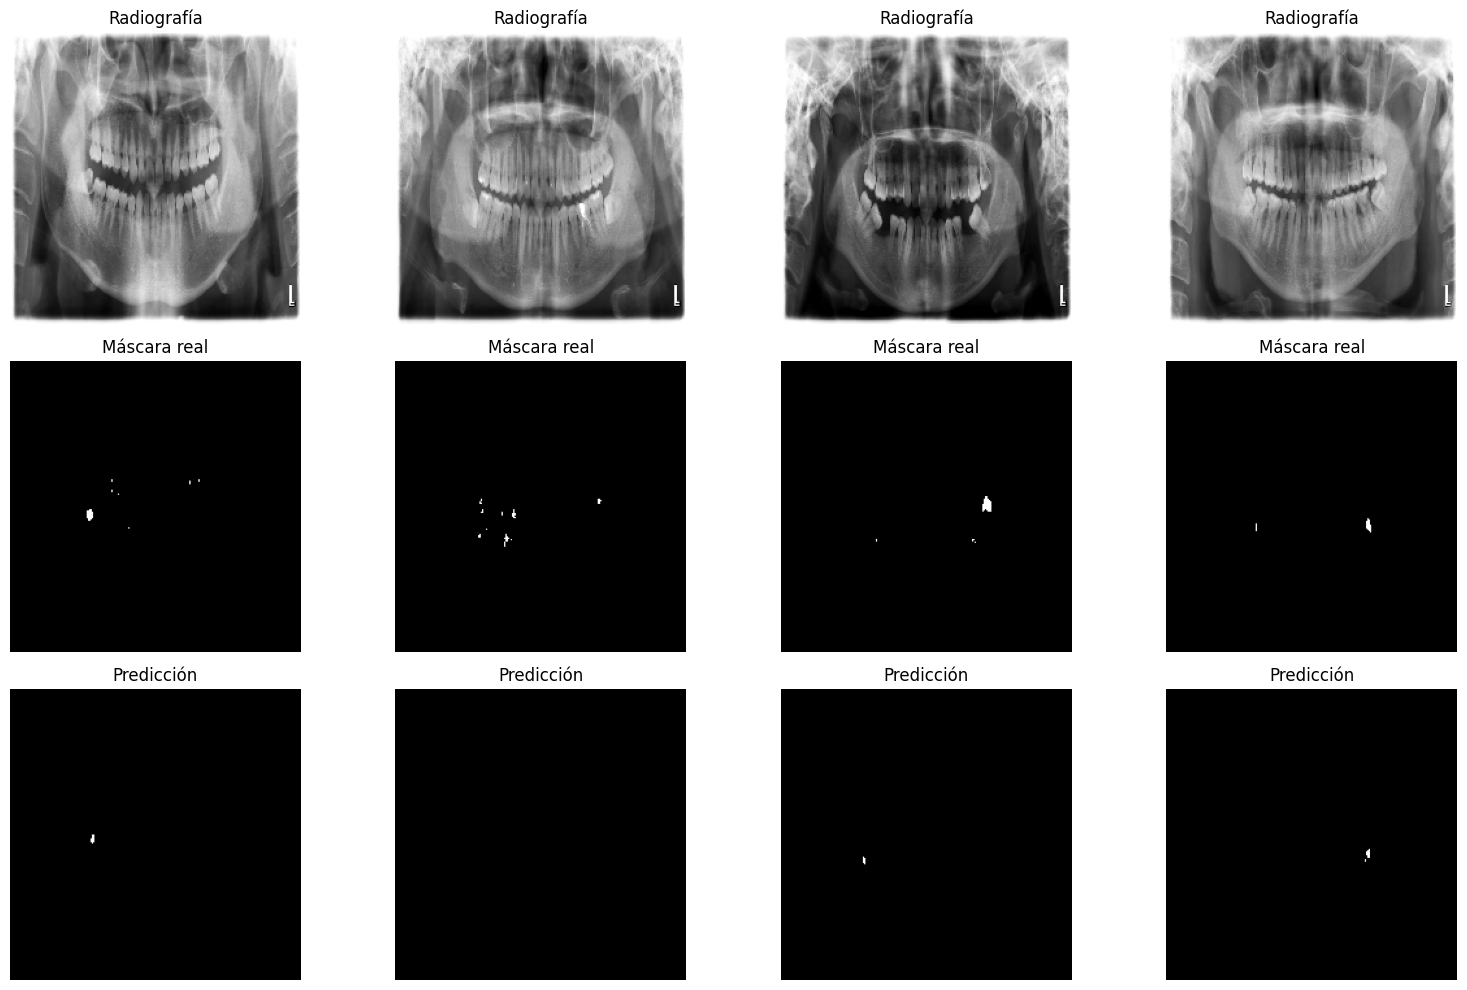

In [20]:
resultados_fine = model.evaluate(val_dataset, return_dict=True)
for metrica, valor in resultados_fine.items():
    print(f"{metrica}: {valor:.4f}")

mostrar_predicciones(val_dataset, n=min(4, BATCH_SIZE))